# **Previsão de Custos Assistenciais e Otimização de Sinistralidade na Saúde Suplementar**

## **Objetivo e Informações Gerais do Projeto**

* Desenvolvimento de um modelo preditivo de IA e Machine Learning focado na previsão de custos hospitalares (Billing Amount) para otimização do índice de sinistralidade e gestão de risco epidemiológico na saúde suplementar.

### **Informações do Dataset (Dicionário de Dados)**

---

* Dataset sintético contendo 55.500 linhas e 15 colunas, projetado para simular dados reais da área da saúde.
* Cada coluna fornece informações específicas sobre o paciente, sua internação e os serviços de saúde prestados.
* Esta estrutura torna o dataset ideal para tarefas de análise de dados, engenharia de recursos e modelagem preditiva aplicadas ao setor de saúde suplementar e controle de sinistralidade.


| Nome da Coluna | Tipo de Dado | Descrição em Português |
| :--- | :--- | :--- |
| **Name** | object | Nome do paciente associado ao registro de saúde. |
| **Age** | int64 | Idade do paciente no momento da internação, expressa em anos. |
| **Gender** | object | Gênero biológico do paciente. |
| **Blood Type** | object | Tipo sanguíneo do paciente. |
| **Medical Condition** | object | Condição médica principal ou diagnóstico primário do paciente. |
| **Date of Admission** | object | A data em que o paciente foi admitido na unidade de saúde. |
| **Doctor** | object | Nome do médico responsável pelos cuidados do paciente durante a internação. |
| **Hospital** | object | Identifica a instituição de saúde ou hospital onde o paciente foi internado. |
| **Insurance Provider** | object | Operadora de plano de saúde ou provedor de seguro do paciente. |
| **Billing Amount** | float64 | **[Variável Alvo]** O valor total faturado pelos serviços médicos durante a internação. Representa o custo bruto do sinistro. |
| **Room Number** | int64 | Número do quarto/leito onde o paciente ficou acomodado. |
| **Admission Type** | object | Especifica o caráter da internação, refletindo as circunstâncias da admissão. |
| **Discharge Date** | object | A data em que o paciente recebeu alta hospitalar. |
| **Medication** | object | Identifica o medicamento principal prescrito ou administrado durante a internação. |
| **Test Results** | object | Descreve o resultado dos exames médicos diagnósticos realizados. |





## **Etapa 1: EDA**

### Leitura e Análise Inicial dos Dados

In [128]:
# importar as bibliotecas

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [129]:
# carregar o arquivo .csv e analisar seus componentes

try:
    df = pd.read_csv('healthcare_dataset.csv')
    print(f"✅ Arquivo carregado com sucesso!")
    print('=' * 55)
    print(f"🔍 Visualização das Primeiras Linhas do Dataframe")
    print('=' * 55)
    display(df.head())
    print('=' * 45)
    print(f"ℹ️ Informações do Dataframe")
    print('=' * 45)
    print(df.info())
    print('=' * 45)
    print(f"📊 Estatísticas Descritivas do Dataframe")
    print('=' * 45)
    print(df.describe())
    print('=' * 45)
    print(f"📐 Dimensões do DataFrame")
    print('=' * 45)
    print(f"Número de Linhas: {df.shape[0]}")
    print(f"Número de Colunas: {df.shape[1]}")
except Exception as e:
    print(f"❌ Erro ao ler o arquivo. Detalhes: {e}")

✅ Arquivo carregado com sucesso!
🔍 Visualização das Primeiras Linhas do Dataframe


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


ℹ️ Informações do Dataframe
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), 

In [130]:
# cópia do dataframe original antes da manipulação para segurança
df_original = df.copy()

In [131]:
# === ANÁLISE E TRATAMENTO INICIAL DOS DADOS ===

# --- 1. Padronização da Nomenclatura das Colunas do Dataframe ---
df.columns = df.columns.str.lower().str.replace(' ','_')
print("✅ Padronização da Nomenclatura das Colunas Concluída\n" + '=' * 65)
print(list(df.columns))
print()

# --- 2. Padronização da Coluna 'name' ---
print("✅ Padronização da Colunas 'name' Concluída\n" + '=' * 65)
print(f"* Antes: {df_original['Name'].head(3).tolist()}")
df['name'] = df['name'].str.lower()
print(f"* Depois: {df['name'].head(3).tolist()}")
print()

# --- 3. Transformar as Colunas 'date_of_admission' e 'discharge_date' para Datetima ---
print("✅ Adequação do Tipo de Dados Concluída\n" + '=' * 65)
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'], errors='coerce')
df['discharge_date'] = pd.to_datetime(df['discharge_date'], errors='coerce')
print(f"* Tipagem da Coluna 'date_of_admission': {df['date_of_admission'].dtype}")
print(f"* Tipagem da Coluna 'discharge_date': {df['discharge_date'].dtype}")
print()

# --- 4. Arredondar Valor de 'billing_amount' ---
print("✅ Valor Arredondado .2f para 'billing_amount' Concluída\n" + '=' * 65)
df['billing_amount'] = df['billing_amount'].round(2)
print(df['billing_amount'].head().tolist())
print()

# --- 5. Checagem de Valores Nulos e Duplicados
print("✅ Conferência de Valores Nulos e Duplicados Concluída\n" + '=' * 65)
df_nulos = df.isna().sum().sum()
df_duplicados = df.duplicated().sum()
print(f"Valores Nulos: {df_nulos}")
print(f"Valores Duplicados: {df_duplicados}")

✅ Padronização da Nomenclatura das Colunas Concluída
['name', 'age', 'gender', 'blood_type', 'medical_condition', 'date_of_admission', 'doctor', 'hospital', 'insurance_provider', 'billing_amount', 'room_number', 'admission_type', 'discharge_date', 'medication', 'test_results']

✅ Padronização da Colunas 'name' Concluída
* Antes: ['Bobby JacksOn', 'LesLie TErRy', 'DaNnY sMitH']
* Depois: ['bobby jackson', 'leslie terry', 'danny smith']

✅ Adequação do Tipo de Dados Concluída
* Tipagem da Coluna 'date_of_admission': datetime64[ns]
* Tipagem da Coluna 'discharge_date': datetime64[ns]

✅ Valor Arredondado .2f para 'billing_amount' Concluída
[18856.28, 33643.33, 27955.1, 37909.78, 14238.32]

✅ Conferência de Valores Nulos e Duplicados Concluída
Valores Nulos: 0
Valores Duplicados: 534


In [132]:
# === ANÁLISE E TRATAMENTO DE VALORES DUPLICADOS ===

# --- 1. Visualização das linhas 100% duplicadas isoladas ---
print("🔍 Análise da amostra de linhas 100% idênticas (Possível erro de sistema):")
print('=' * 75)

# Filtra apenas as linhas duplicadas para exibição analítica
df_duplicados_completos = df[df.duplicated(keep=False)].sort_values(by='name')
display(df_duplicados_completos.head(6))
print()

# Armazena a quantidade exata de linhas duplicadas antes de dropar
qtd_duplicados = df.duplicated().sum()
formato_original = df.shape

# --- 2. Remoção dos valores duplicados exatos do DataFrame Principal ---
df = df.drop_duplicates()

# --- 3. Conferência e Conclusão da Etapa ---
print("✅ Conferência de Valores Duplicados Dropados Concluída\n" + "=" * 65)
print(f"* Formato original do DataFrame:        {formato_original[0]} linhas e {formato_original[1]} colunas")
print(f"* Quantidade de linhas duplicadas:      {qtd_duplicados}\n" + '-' * 65)
print(f"* Novo formato após o tratamento:       {df.shape[0]} linhas e {df.shape[1]} colunas")
print(f"* Validação final (Duplicados atuais):  {df.duplicated().sum()}")

🔍 Análise da amostra de linhas 100% idênticas (Possível erro de sistema):


,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
42407,abigail young,41,Female,O+,Hypertension,2022-12-15,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.57,192,Elective,2023-01-13,Ibuprofen,Normal
54285,abigail young,41,Female,O+,Hypertension,2022-12-15,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.57,192,Elective,2023-01-13,Ibuprofen,Normal
40385,adam thomas,75,Male,O+,Hypertension,2022-01-02,Beverly Miller,Sanchez-Wilson,Cigna,16294.91,180,Urgent,2022-01-30,Ibuprofen,Normal
53139,adam thomas,75,Male,O+,Hypertension,2022-01-02,Beverly Miller,Sanchez-Wilson,Cigna,16294.91,180,Urgent,2022-01-30,Ibuprofen,Normal
55298,alex black,51,Male,O+,Diabetes,2022-03-27,Frank Williams,Short and Sons,Aetna,39525.67,246,Emergency,2022-04-21,Aspirin,Normal
24779,alex black,51,Male,O+,Diabetes,2022-03-27,Frank Williams,Short and Sons,Aetna,39525.67,246,Emergency,2022-04-21,Aspirin,Normal



✅ Conferência de Valores Duplicados Dropados Concluída
* Formato original do DataFrame:        55500 linhas e 15 colunas
* Quantidade de linhas duplicadas:      534
-----------------------------------------------------------------
* Novo formato após o tratamento:       54966 linhas e 15 colunas
* Validação final (Duplicados atuais):  0


In [133]:
# === ANÁLISE DE VALORES OCULTOS ===

# Verificar os valores únicos de colunas categóricas para identificar se há valores "nulos disfarçados"
print("✅ Conferência de Possíveis Valores Ocultos Concluída\n" + "=" * 65)
for col in ['gender', 'blood_type', 'medical_condition', 'insurance_provider', 'admission_type', 'medication', 'test_results']:
    print(f"* Valores Únicos em {col}: {df[col].unique()}")

✅ Conferência de Possíveis Valores Ocultos Concluída
* Valores Únicos em gender: ['Male' 'Female']
* Valores Únicos em blood_type: ['B-' 'A+' 'A-' 'O+' 'AB+' 'AB-' 'B+' 'O-']
* Valores Únicos em medical_condition: ['Cancer' 'Obesity' 'Diabetes' 'Asthma' 'Hypertension' 'Arthritis']
* Valores Únicos em insurance_provider: ['Blue Cross' 'Medicare' 'Aetna' 'UnitedHealthcare' 'Cigna']
* Valores Únicos em admission_type: ['Urgent' 'Emergency' 'Elective']
* Valores Únicos em medication: ['Paracetamol' 'Ibuprofen' 'Aspirin' 'Penicillin' 'Lipitor']
* Valores Únicos em test_results: ['Normal' 'Inconclusive' 'Abnormal']


In [134]:
# === ANÁLISE DE INCONSISTÊNCIAS TEMPORAIS ===

# As datas de alta hospitalar não podem ser anteriores às datas de admissão
inconsistencias_data = df[df['discharge_date'] < df['date_of_admission']]
print("✅ Conferência de Inconsistências Temporais Concluída\n" + '=' * 75)
print(f"Linhas com datas inconsistentes: {inconsistencias_data.shape[0]}")

✅ Conferência de Inconsistências Temporais Concluída
Linhas com datas inconsistentes: 0


In [135]:
# === INVESTIGAÇÃO DE FATURAMENTO NEGATIVO (BILLING AMOUNT < 0) ===

# 1. Filtragem das linhas com valores negativos
df_billing_negativo = df[df['billing_amount'] < 0]

print("🔍 Investigação de Faturamento Negativo:\n" + '=' *65)
print(f"* Quantidade de registros com faturamento negativo: {df_billing_negativo.shape[0]}")
print(f"* Menor valor encontrado: R$ {df_billing_negativo['billing_amount'].min():,.2f}")
print()

# 2. Visualizar uma amostra dessas linhas para entender o padrão
print("\n🔍 Amostra dos registros negativos:\n" + '=' * 65)
display(df_billing_negativo.head(5))

# 3. Análise de Contexto: Investigação de Padrões Associados ao Faturamento Negativo
print("\n📊 Distribuição por Operadora de Saúde (Insurance Provider):\n" + '=' * 65)
print(df_billing_negativo['insurance_provider'].value_counts())

print("\n📊 Distribuição por Tipo de Admissão (Admission Type):\n" + '=' * 65)
print(df_billing_negativo['admission_type'].value_counts())

print("\n📊 Distribuição por Resultado do Teste (Test Results):\n" + '=' * 65)
print(df_billing_negativo['test_results'].value_counts())

🔍 Investigação de Faturamento Negativo:
* Quantidade de registros com faturamento negativo: 106
* Menor valor encontrado: R$ -2,008.49


🔍 Amostra dos registros negativos:


,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
132,ashley erickson,32,Female,AB-,Cancer,2019-11-05,Gerald Hooper,"and Johnson Moore, Branch",Aetna,-502.51,376,Urgent,2019-11-23,Penicillin,Normal
799,christopher weiss,49,Female,AB-,Asthma,2023-02-16,Kelly Thompson,Hunter-Hughes,Aetna,-1018.25,204,Elective,2023-03-09,Penicillin,Inconclusive
1018,ashley warner,60,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.36,426,Elective,2022-01-11,Ibuprofen,Normal
1421,jay galloway,74,Female,O+,Asthma,2021-01-20,Debra Everett,Group Peters,Blue Cross,-109.10,381,Emergency,2021-02-09,Ibuprofen,Abnormal
2103,joshua williamson,72,Female,B-,Diabetes,2021-03-21,Wendy Ramos,"and Huff Reeves, Dennis",Blue Cross,-576.73,369,Urgent,2021-04-17,Aspirin,Abnormal



📊 Distribuição por Operadora de Saúde (Insurance Provider):
insurance_provider
Aetna               27
Cigna               24
Medicare            21
UnitedHealthcare    19
Blue Cross          15
Name: count, dtype: int64

📊 Distribuição por Tipo de Admissão (Admission Type):
admission_type
Urgent       38
Elective     36
Emergency    32
Name: count, dtype: int64

📊 Distribuição por Resultado do Teste (Test Results):
test_results
Inconclusive    39
Abnormal        38
Normal          29
Name: count, dtype: int64


In [136]:
# === REMOÇÃO DE REGISTROS COM FATURAMENTO INCONSISTENTE (NEGATIVO) ===
# Nota de Negócio: Eliminação de ruídos (glosas médicas totais ou erros de sistema),
# que distorceriam a modelagem de custo bruto do sinistro.

# 1. Identificação do volume antes da exclusão
percentual_negativo = (df_billing_negativo.shape[0] / df.shape[0]) * 100
print('=' * 70)
print("🔍 Investigação da Representatividade de Registros Inconsistentes:\n" + '=' * 70)
print(f"Representatividade: {percentual_negativo:.2f}%")
print()

# 2. Aplicando o filtro para manter apenas faturamento estritamente positivo
# Nota de Negócio: Registros negativos (106 linhas) foram tratados como anomalias de sistema 
# (possíveis glosas médicas ou erros de integração) e desconsiderados para fins de modelagem de sinistralidade.
df_clean = df[df['billing_amount'] >= 0].copy()

# 3. Conferência e Conclusão da Etapa
print('=' * 70)
print("✅ Tratamento de Valores Negativos Concluído\n" + '=' * 70)
print(f"* Registros inconsistentes identificados (Glosa/Erro): {df_billing_negativo.shape[0]}")
print(f"* Formato do DataFrame antes do tratamento:            {df.shape[0]} linhas")
print(f"* Novo formato após remoção dos negativos:             {df_clean.shape[0]} linhas")
print(f"* Validação final (registros inconsistentes atual):    {df_clean[df_clean['billing_amount'] < 0].shape[0]}")



🔍 Investigação da Representatividade de Registros Inconsistentes:
Representatividade: 0.19%

✅ Tratamento de Valores Negativos Concluído
* Registros inconsistentes identificados (Glosa/Erro): 106
* Formato do DataFrame antes do tratamento:            54966 linhas
* Novo formato após remoção dos negativos:             54860 linhas
* Validação final (registros inconsistentes atual):    0


### Feature Engineering

✅ Criação de Feature de Contagem de Dias de Internação Concluída: 'lengh_of_stay'
🔍 Análise das primeiras linhas da nova feature:


,date_of_admission,discharge_date,length_of_stay
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


📊 Resumo estatístico do tempo de internação (em dias):
count    54860.000000
mean        15.498815
std          8.661357
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: length_of_stay, dtype: float64


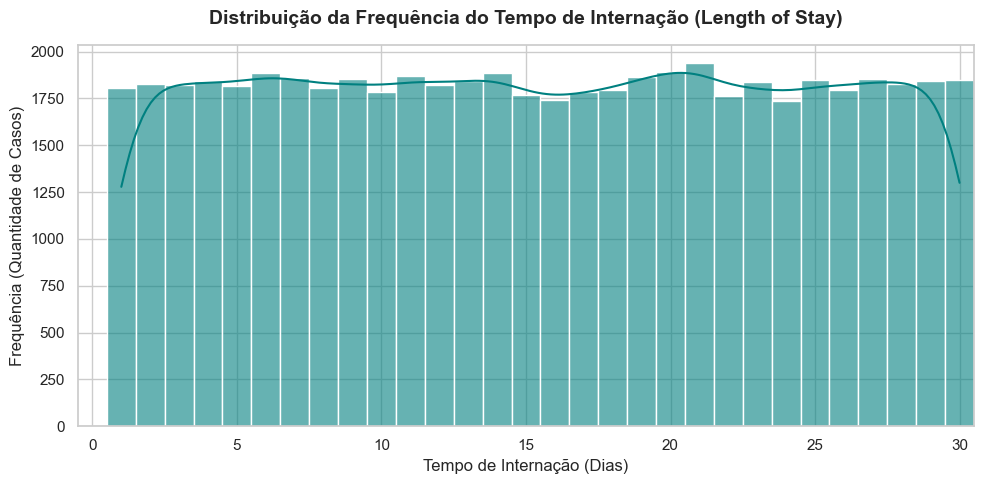

In [ ]:
# === FEATURE ENGINEERING: TEMPO DE INTERNAÇÃO (DIAS) ===

# --- 1. Criação da feature 'length_of_stay' (Dias de Internação)
# Nota de Negócio: Geração do indicador de Tempo de Internação, um dos 
# principais drivers de custo e severidade do sinistro na saúde complementar.
df_clean['length_of_stay'] = (df_clean['discharge_date'] - df_clean['date_of_admission']).dt.days
print("✅ Criação de Feature de Contagem de Dias de Internação Concluída: 'lengh_of_stay'\n" + '=' * 85)


print("🔍 Análise das primeiras linhas da nova feature:")
print('=' * 85)
display(df_clean[['date_of_admission', 'discharge_date', 'length_of_stay']].head())

# --- 2. Análise Descritiva da Nova Variável
print('=' * 60)
print("📊 Resumo estatístico do tempo de internação (em dias):\n" + '=' * 60)
print(df_clean['length_of_stay'].describe())

# --- 3. Visualização dos Dados
# Configuração do estilo visual
sns.set_theme(style="whitegrid")

# Criação a área do gráfico
fig, ax = plt.subplots(figsize=(10, 5))

# Plot do Histograma com linha de densidade (KDE)
sns.histplot(
    data=df_clean, 
    x='length_of_stay', 
    kde=True, 
    discrete=True,  # garante que cada barra represente exatamente 1 dia
    color='teal',
    alpha=0.6,
    ax=ax
)

# Customização de títulos e rótulos para apresentação
ax.set_title('Distribuição da Frequência do Tempo de Internação (Length of Stay)', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Tempo de Internação (Dias)', fontsize=12)
ax.set_ylabel('Frequência (Quantidade de Casos)', fontsize=12)

# Ajuste do limite do eixo X para focar onde estão os dados
ax.set_xlim(-0.5, df_clean['length_of_stay'].max() + 0.5)

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.savefig('grafico_tempo_de_internacao.png', dpi=300)
plt.show()

✅ Criação de Feature de Conversão de Moeda Dólar para Real Concluída: 'billing_amount_br'
📊 Validação da conversão monetária:
   billing_amount  billing_amount_br
0        18856.28           94281.40
1        33643.33          168216.65
2        27955.10          139775.50
3        37909.78          189548.90
4        14238.32           71191.60
------------------------------------------------------------
* Média de custos por internação (em Dólar - $): 25594.63
* Média de custos por internação (em Real - R$): 127973.17
------------------------------------------------------------
* Valor Mínimo (em R$): 46.20
* Valor Máximo (em R$): 263821.40


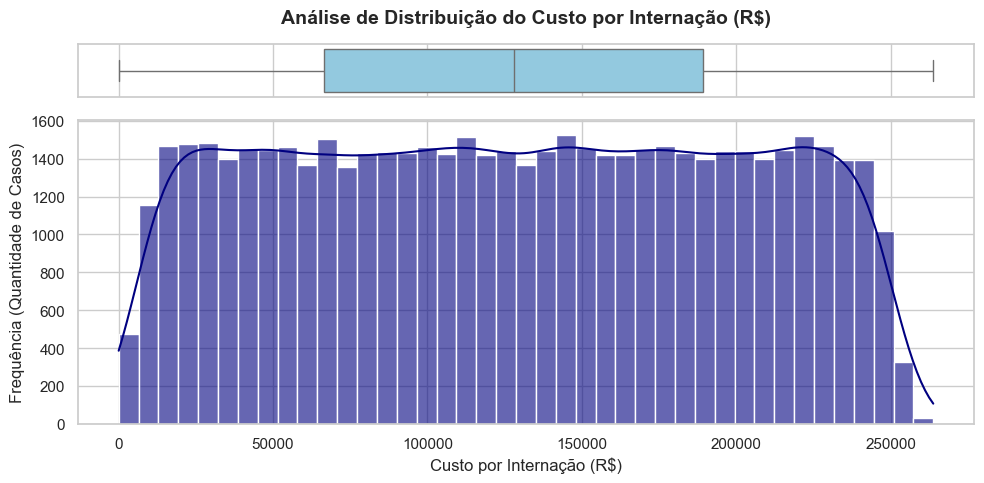

In [178]:
# === FEATURE ENGINEERING: CUSTO POR INTERNAÇÃO (EM REAL - R$) ===

# --- 1. Criação da feature 'billing_amount_br' conversão de dólar para real (Moeda Brasileira)
# Nota de Negócio: a conversão irá trazer maior tangibilidade para o modelo, 
# conforme a realidade brasileira.

# --- 2. Definição da taxa de câmbio de referência
taxa_cambio = 5.00  # Ajuste para a taxa média de fechamento do período do dataset

# --- 3. Criação da nova coluna da nova feature
df_clean.loc[:, 'billing_amount_br'] = df_clean['billing_amount'] * taxa_cambio

# --- 4. Arredondando para duas casas decimais
df_clean.loc[:, 'billing_amount_br'] = df_clean['billing_amount_br'].round(2)

# --- 5. Conferência da Nova Variável

print("✅ Criação de Feature de Conversão de Moeda Dólar para Real Concluída: 'billing_amount_br'\n" + '=' * 90)
print(f"📊 Validação da conversão monetária:\n" + '=' * 90)
print(df_clean[['billing_amount', 'billing_amount_br']].head())
print('-' * 60)
print(f"* Média de custos por internação (em Dólar - $): {df_clean['billing_amount'].mean():.2f}")
print(f"* Média de custos por internação (em Real - R$): {df_clean['billing_amount_br'].mean():.2f}")
print('-' * 60)
print(f"* Valor Mínimo (em R$): {df_clean['billing_amount_br'].min():.2f}")
print(f"* Valor Máximo (em R$): {df_clean['billing_amount_br'].max():.2f}")

# --- 6. Visualização dos Dados

# Configuração do estilo visual
sns.set_theme(style="whitegrid")

# Criação da figura com 2 subplots empilhados (Boxplot em cima, Histograma embaixo)
# O argumento 'sharex=True' garante que os eixos X fiquem adequadamente alinhados
fig, (ax_box, ax_hist) = plt.subplots(
    2, 1, 
    figsize=(10, 5), 
    sharex=True, 
    gridspec_kw={"height_ratios": (.15, .85)} # permite mais espaço para o histograma
)

# Plot do Boxplot no topo
sns.boxplot(x=df_clean['billing_amount_br'], ax=ax_box, color='skyblue')
ax_box.set(xlabel='') # remove o rótulo do X superior para não duplicar texto
ax_box.set_title('Análise de Distribuição do Custo por Internação (R$)', fontsize=14, pad=15, fontweight='bold')

# Plot do Histograma com a linha KDE embaixo
sns.histplot(
    data=df_clean, 
    x='billing_amount_br', 
    kde=True, 
    ax=ax_hist, 
    color='navy', 
    alpha=0.6
)
ax_hist.set_xlabel('Custo por Internação (R$)', fontsize=12)
ax_hist.set_ylabel('Frequência (Quantidade de Casos)', fontsize=12)

# Ajustes finais de layout e salvamento seguro
plt.tight_layout()
plt.savefig('grafico_custo_por_internacao.png', dpi=300, bbox_inches='tight')
plt.show()


**=== Interpretação do Gráfico Histograma: Distribuição do Custo por Internação (R$) ===**

* Histograma: as barras mantêm praticamente a mesma altura (em torno de 1.400 casos). A linha de densidade (KDE) é quase uma linha reta horizontal no topo (histograma plano).
* Boxplot: a linha da mediana está exatamente no centro da caixa azul (por volta de R$ 128.000), os quartis possuem larguras idênticas e os "bigodes" têm o mesmo comprimento, sem a presença de nenhum outlier.

* **`Nota Técnica:`** a ausência de assimetria e de outliers nessa métrica isolada reitera a necessidade de executar a engenharia de features, para combinar o faturamento a outras métricas para extrair o real comportamento de severidade e risco da carteira.

In [179]:
# === FEATURE ENGINEERING: CUSTO DIÁRIO DE INTERNAÇÃO (EM REAL - R$) ===

# --- 1. Criação da Feature para Análise do Custo Diário em Reais (cost_per_day_br)
# Nota de Negócio: a proposta é normalizar o custo pelo tempo
# Nota Técnica: 'billing_amount_br' dividido pelo tempo de internação ('length_of_stay')

# --- 2. Criação da nova coluna da nova feature
df_clean.loc[:, 'cost_per_day_br'] = df_clean['billing_amount_br'] / df_clean['length_of_stay']

# --- 3. Arredondando para duas casas decimais para manter o padrão monetário
df_clean.loc[:, 'cost_per_day_br'] = df_clean['cost_per_day_br'].round(2)

print("✅ Criação da Feature 'cost_per_day_br' Concluída")
print('=' * 80)

# --- 4. Análise Descritiva da Nova Variável
print("📊 Resumo estatístico do custo diário (em R$):")
print('-' * 80)
print(df_clean['cost_per_day_br'].describe())
print('=' * 80)

# Visualização das primeiras linhas para conferência de sanidade
print("\n🔍 Amostra das variáveis financeiras cruzadas:")
print('-' * 80)
print(df_clean[['length_of_stay', 'billing_amount_br', 'cost_per_day_br']].head())

✅ Criação da Feature 'cost_per_day_br' Concluída
📊 Resumo estatístico do custo diário (em R$):
--------------------------------------------------------------------------------
count     54860.000000
mean      16995.664895
std       29007.171947
min           4.750000
25%        4299.507500
50%        8264.670000
75%       16060.707500
max      261059.250000
Name: cost_per_day_br, dtype: float64

🔍 Amostra das variáveis financeiras cruzadas:
--------------------------------------------------------------------------------
   length_of_stay  billing_amount_br  cost_per_day_br
0               2           94281.40         47140.70
1               6          168216.65         28036.11
2              15          139775.50          9318.37
3              30          189548.90          6318.30
4              20           71191.60          3559.58


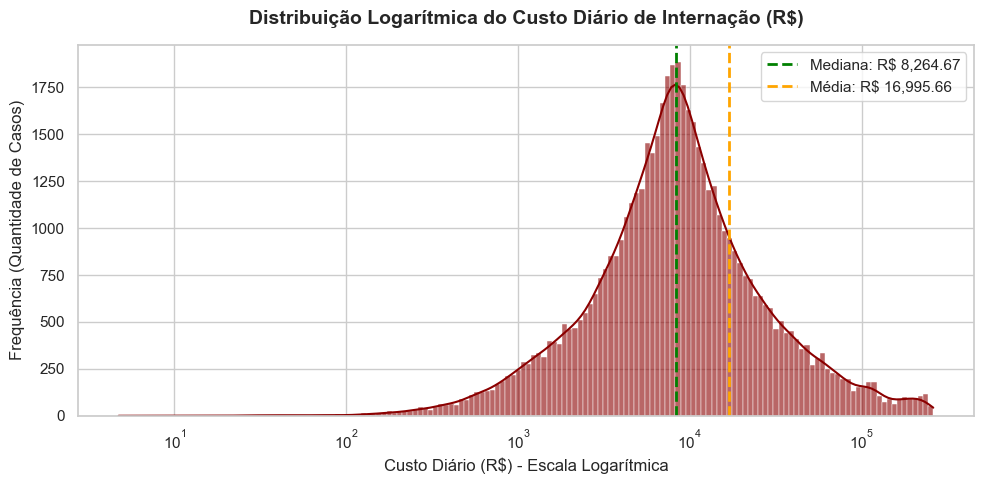

In [195]:
# --- 4. Visualização dos Dados
# Configuração do estilo visual
sns.set_theme(style="whitegrid")

# Criação a área do gráfico
fig, ax = plt.subplots(figsize=(10, 5))

# Plot do Histograma com Escala Logarítmica
sns.histplot(
    data=df_clean, 
    x='cost_per_day_br', 
    kde=True, 
    log_scale=True,  # ideal para lidar com a assimetria e o máximo de R$ 261k
    color='darkred', # cor que remete a custo/criticidade
    alpha=0.6,
    ax=ax
)

# Adicionando linhas verticais para marcar os principais pontos estatísticos (Métricas de Negócio)
mediana = df_clean['cost_per_day_br'].median()
media = df_clean['cost_per_day_br'].mean()

ax.axvline(mediana, color='green', linestyle='--', linewidth=2, label=f'Mediana: R$ {mediana:,.2f}')
ax.axvline(media, color='orange', linestyle='--', linewidth=2, label=f'Média: R$ {media:,.2f}')

# Customização de títulos e rótulos para apresentação
ax.set_title('Distribuição Logarítmica do Custo Diário de Internação (R$)', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Custo Diário (R$) - Escala Logarítmica', fontsize=12)
ax.set_ylabel('Frequência (Quantidade de Casos)', fontsize=12)

# Ativação da legenda das linhas de média e mediana
ax.legend(fontsize=11, loc='upper right')

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.savefig('grafico_custo_diario_log.png', dpi=300, bbox_inches='tight')
plt.show()

**=== Interpretação do Gráfico Histograma: Distribuição Logarítmica do Custo Diário de Internação (R$) ===**

* A Mediana (Linha Verde - R$ 8.264,67): mostra que exatamente metade das diárias de internação custa menos que esse valor, e a outra metade custa mais. Ela representa o "comportamento típico" do segurado comum. <br>
* A Média (Linha Laranja - R$ 16.995,66): esta foi puxada para a direita e é mais que o dobro da mediana.

* **`Insight de Negócio:`** Comprovação do impacto dos sinistros de alto custo. Poucos pacientes (a cauda longa à direita) gastam tanto que conseguem distorcer a média de custos de toda a operadora.

In [183]:
# === FEATURE ENGINEERING: AGRUPAMENTO EM FAIXAS DE IDADE (RN 563, ANS) ===

# --- 1. Criação da Feature 'age_group'
# Nota de Negócio: Definição dos limites (bins) e rótulos (labels), conforme a RN 563 da ANS.
# Nota Técnica: O primeiro bin começa em -1 para incluir a idade 0,
# limitado ao teto biológico realista de 120 anos.
bins_ans = [-1, 18, 23, 28, 33, 38, 43, 48, 53, 58, 120]

# --- 2. Criação da lista de rótulos para nomear as fronteiras de idade (bins)
labels_ans = [
    '0 a 18 anos',   '19 a 23 anos',  '24 a 28 anos',  '29 a 33 anos',  '34 a 38 anos',
    '39 a 43 anos',  '44 a 48 anos',  '49 a 53 anos',  '54 a 58 anos',  '59 anos ou mais'
]

# pd.cut encaixa as idades correspondentes conforme a lista da variável labels_ans
df_clean.loc[:, 'age_group'] = pd.cut(df_clean['age'], bins=bins_ans, labels=labels_ans)

print("✅ Criação da Feature 'age_group' (Padrão ANS) Concluída")
print('=' * 80)

# --- 3. Análise Descritiva da Distribuição da Carteira
print("📊 Distribuição de Frequência por Faixa Etária:")
print('=' * 80)
contagem = df_clean['age_group'].value_counts().sort_index()
proporcao = df_clean['age_group'].value_counts(normalize=True).sort_index() * 100

# .zip une as 3 informações em uma única linha para cada loop
for faixa, qtd, prop in zip(contagem.index, contagem.values, proporcao.values):
    print(f"* {faixa:<16} | Beneficiários: {qtd:<6} | Representatividade: {prop:.2f}%")
print('-' * 80)

# --- 4. Cruzamento Estratégico: Custo Médio e Tempo de Internação por Faixa Etária
print("\n📊 Distribuição de Internação e Custos por Faixa Etária (Média):")
print('=' * 80)
analise_sinistro = df_clean.groupby(                             # separa o df nos 10 subgrupos de faixa etária
    'age_group', observed=False)[                                # garante que se a linha estiver vazia, aparecerá no print
    ['length_of_stay', 'billing_amount_br', 'cost_per_day_br']   # filtra para calcular as métricas apenas dessas três colunas
    ].mean().round(2)                                            # calcula o valor médio e arredonda em duas casas decimais                      
print(analise_sinistro)

✅ Criação da Feature 'age_group' (Padrão ANS) Concluída
📊 Distribuição de Frequência por Faixa Etária:
* 0 a 18 anos      | Beneficiários: 885    | Representatividade: 1.61%
* 19 a 23 anos     | Beneficiários: 3938   | Representatividade: 7.18%
* 24 a 28 anos     | Beneficiários: 3987   | Representatividade: 7.27%
* 29 a 33 anos     | Beneficiários: 3906   | Representatividade: 7.12%
* 34 a 38 anos     | Beneficiários: 4224   | Representatividade: 7.70%
* 39 a 43 anos     | Beneficiários: 3929   | Representatividade: 7.16%
* 44 a 48 anos     | Beneficiários: 4014   | Representatividade: 7.32%
* 49 a 53 anos     | Beneficiários: 4067   | Representatividade: 7.41%
* 54 a 58 anos     | Beneficiários: 4205   | Representatividade: 7.66%
* 59 anos ou mais  | Beneficiários: 21705  | Representatividade: 39.56%
--------------------------------------------------------------------------------

📊 Distribuição de Internação e Custos por Faixa Etária (Média):
                 length_of_stay  billing

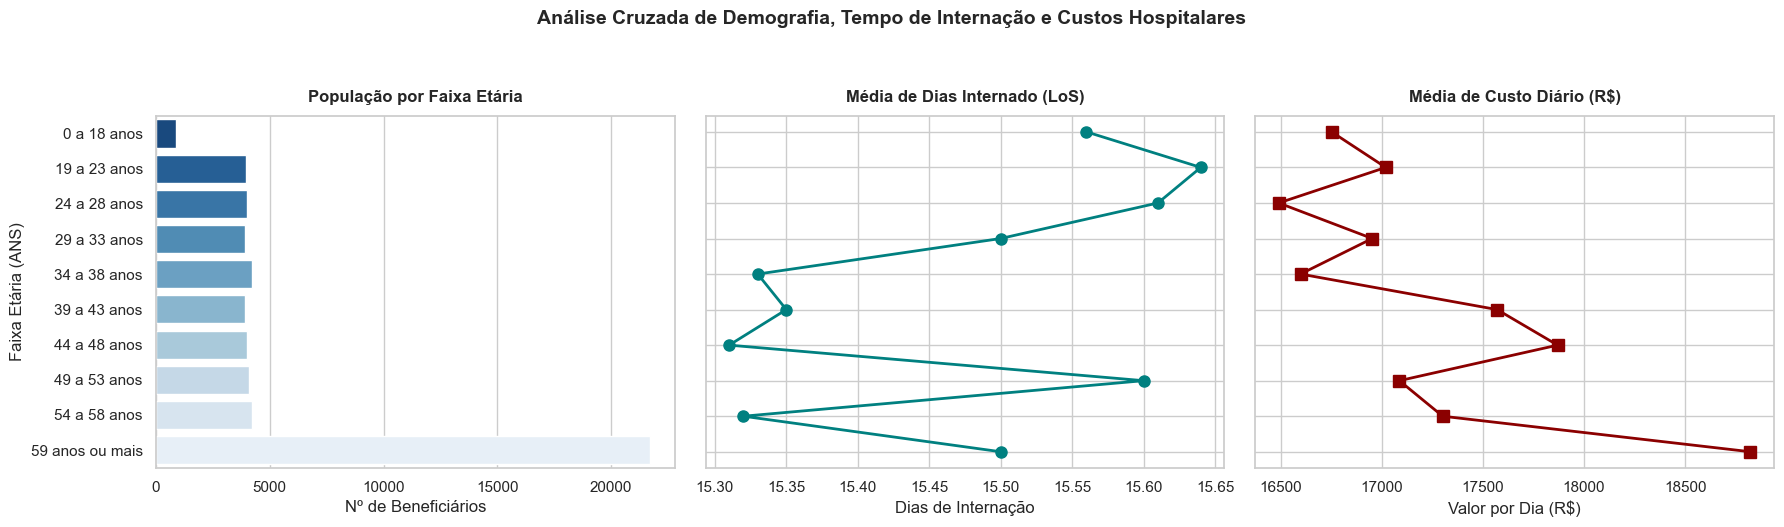

In [189]:
# --- 5. Visualização dos Dados
# Configuração do estilo visual
sns.set_theme(style="whitegrid")

# Criação da figura com 1 linha e 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

# Preparação dos dados agregados para facilitar o plot
df_plot = analise_sinistro.reset_index()
# Adição da contagem de beneficiários ao df_plot para centralizar os dados
df_plot['qtd_beneficiarios'] = df_clean['age_group'].value_counts().sort_index().values

# --- PLOT 1: Quantidade de Beneficiários (Barras) ---
sns.barplot(
    data=df_plot, 
    x='qtd_beneficiarios', 
    y='age_group', 
    ax=axes[0], 
    palette='Blues_r',
    hue='age_group',    # define a cor baseada na própria faixa etária
    legend=False        # remove a legenda repetida que o hue cria automaticamente
)
axes[0].set_title('População por Faixa Etária', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Nº de Beneficiários')
axes[0].set_ylabel('Faixa Etária (ANS)')

# --- PLOT 2: Média de Tempo de Permanência (Linha com Marcador) ---
axes[1].plot(df_plot['length_of_stay'], df_plot['age_group'], marker='o', color='teal', linewidth=2, markersize=8)
axes[1].set_title('Média de Dias Internado (LoS)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Dias de Internação')
axes[1].set_yticklabels([]) # remove rótulos repetidos do eixo Y

# --- PLOT 3: Média de Custo Diário (Linha com Marcador) ---
axes[2].plot(df_plot['cost_per_day_br'], df_plot['age_group'], marker='s', color='darkred', linewidth=2, markersize=8)
axes[2].set_title('Média de Custo Diário (R$)', fontsize=12, fontweight='bold', pad=10)
axes[2].set_xlabel('Valor por Dia (R$)')
axes[2].set_yticklabels([]) # remove rótulos repetidos do eixo Y

# Título Geral da Figura
plt.suptitle('Análise Cruzada de Demografia, Tempo de Internação e Custos Hospitalares', fontsize=14, fontweight='bold', y=1.05)

# Ajustes finais de layout e salvamento seguro
plt.tight_layout()
plt.savefig('grafico_analise_cruzada_faixa_etaria.png', dpi=300, bbox_inches='tight')
plt.show()

**=== Interpretação do Gráficos de Análise Cruzada: Demografia, Tempo de Internação e Custos Hospitalares ===**

* População por faixa etária: concentração dos clientes com 59 anos ou mais.<br>
* O tempo de internação varia minimamente entre 15.30 e 15.65 dias, e o custo diário varia entre R$ 16.500 e R$ 18.800. <br>

* **`Nota Técnica:`** as oscilações que parecem "picos e vales" nos gráficos de linha são, na verdade, microvariações geradas sem impacto significativo para o modelo ou diagnóstico do perfil do cliente.

* **`Nota Técnica:`** embora a operadora enfrente um desafio demográfico severo, com uma concentração massiva de beneficiários na faixa de 59 anos ou mais (39.56%), o consumo de recursos hospitalares não é ditado pela idade cronológica. O tempo de permanência e o custo diário médio são homogêneos entre as gerações. Isso prova que o risco atuarial e a sinistralidade desta carteira são governados pela gravidade clínica individual e não pelo envelhecimento da base. <br>

* **`Insight de Negócio:`** com quase 40% da carteira concentrada no grupo de 59 anos ou mais, as operadoras enfrentam um risco severo de descapitalização futura, dado que a sinistralidade crônica dessa população tende a se manifestar no ecossistema de saúde geral. <br>



In [192]:
# === FEATURE ENGINEERING: ATENDIMENTO DE DIA DE SEMANA (0/1) ===

# --- 1. Criação da Feature 'is_weekend_admission'
# Nota de Negócio: Hospitais operam em regime de plantão, exames podem demorar para serem liberados, 
# e a equipe médica de retaguarda costuma cobrar taxas diferenciadas
# Nota Técnica: Variável binária que indica se o paciente deu entrada no hospital no sábado ou no domingo,
# Criação de Flag de Admissão no Final de Semana (Sábado = 5, Domingo = 6)

# --- 2. Criação da nova coluna da nova feature
df_clean.loc[:, 'is_weekend_admission'] = (df_clean['date_of_admission'].dt.weekday >= 5).astype(int)

# --- 3. Análise Descritiva da Nova Variável
print("✅ Criação da Feature 'is_weekend_admission' (Padrão ANS) Concluída\n" + '=' * 70)
print((df_clean['is_weekend_admission']).value_counts())

print("\n📊 Distribuição do Dia de Internação (0/1) por Custos Diários (Média):\n" + '=' * 70)
print(df_clean.groupby('is_weekend_admission')[['cost_per_day_br']].mean().round(2))

✅ Criação da Feature 'is_weekend_admission' (Padrão ANS) Concluída
is_weekend_admission
0    39212
1    15648
Name: count, dtype: int64

📊 Distribuição do Dia de Internação (0/1) por Custos Diários (Média):
                      cost_per_day_br
is_weekend_admission                 
0                            17060.34
1                            16833.59


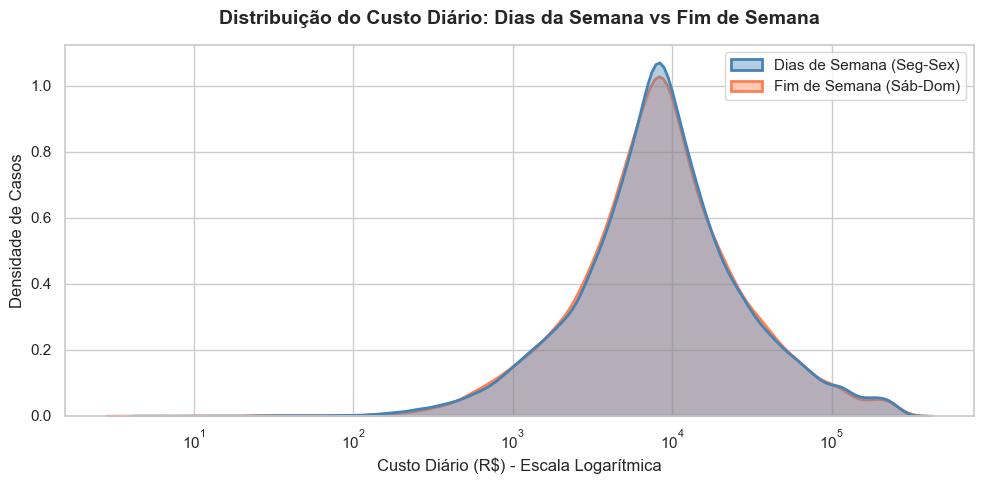

In [ ]:
# --- 4. Visualização dos Dados

# Configurando o estilo visual
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))

# Plot das curvas de densidade para os dois grupos
sns.kdeplot(
    data=df_clean,
    x='cost_per_day_br',
    hue='is_weekend_admission',
    fill=True,
    common_norm=False, # garante que as áreas sejam proporcionais ao seu próprio grupo
    palette={0: 'steelblue', 1: 'coral'},
    alpha=0.4,
    linewidth=2,
    log_scale=True, # mantém a consistência com a escala logarítmica
    ax=ax
)

# Customização de títulos e rótulos para apresentação
ax.set_title('Distribuição do Custo Diário: Dias da Semana vs Fim de Semana', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Custo Diário (R$) - Escala Logarítmica', fontsize=12)
ax.set_ylabel('Densidade de Casos', fontsize=12)

# Customização da legenda para termos termos claros de negócio
legend = ax.get_legend()
legend.set_title(False)
for t, label in zip(legend.get_texts(), ["Dias de Semana (Seg-Sex)", "Fim de Semana (Sáb-Dom)"]):
    t.set_text(label)

plt.tight_layout()
plt.savefig('grafico_dias_da_semana.png', dpi=300, bbox_inches='tight')
plt.show()

**=== Interpretação do Gráfico: Distribuição do Custo Diário (Dias da Semana vs Fim de Semana) ===**

* As curvas azul (Dias de Semana) e laranja (Fim de Semana) se sobrepõem de forma quase milimétrica. <br>

* **`Nota Técnica:`** No mercado de saúde, existe uma tese forte de que internações que começam no sábado ou domingo são mais ineficientes e caras (menos médicos de rotina, exames parados, taxas de plantão). Esse gráfico derruba essa tese para a sua base de dados. <br>

* **`Nota Técnica:`** Na extremidade direita do gráfico, ambas as curvas fazem uma pequena oscilação antes de encerar no zero. Isso mostra que a ocorrência de sinistros catastróficos de alto custo acontece na mesma proporção e com a mesma intensidade, em qualquer dia da semana. <br>

In [ ]:
# === FEATURE ENGINEERING: TEMPO PROLONGADO DE INTERNAÇÃO (0/1) ===

# --- 1. Criação da Feature 'is_long_stay'
# Nota de Negócio: Internações prolongadas tendem a ter procedimentos mais onerosos ao plano
# Nota Técnica: Criação de Flag de Internação Prolongada (acima do percentil 75% que é 23 dias)

# --- 2. Criação da nova coluna da nova feature
df_clean.loc[:, 'is_long_stay'] = (df_clean['length_of_stay'] > 23).astype(int)

print("✅ Criação da Feature 'is_long_stay' Concluída\n" + '=' * 80)
print((df_clean['is_long_stay']).value_counts().round(2))

print("\n📊 Distribuição de Internação Prolongada (0/1) por Custos  Diários (Média):\n" + '=' * 80)
print(df_clean.groupby('is_long_stay')[['cost_per_day_br']].mean().round(2))

✅ Criação da Feature 'is_long_stay' Concluída
is_long_stay
0    42104
1    12756
Name: count, dtype: int64

📊 Distribuição de Internação Prolongada (0/1) por Custos  Diários (Média):
              cost_per_day_br
is_long_stay                 
0                    20706.34
1                     4747.77


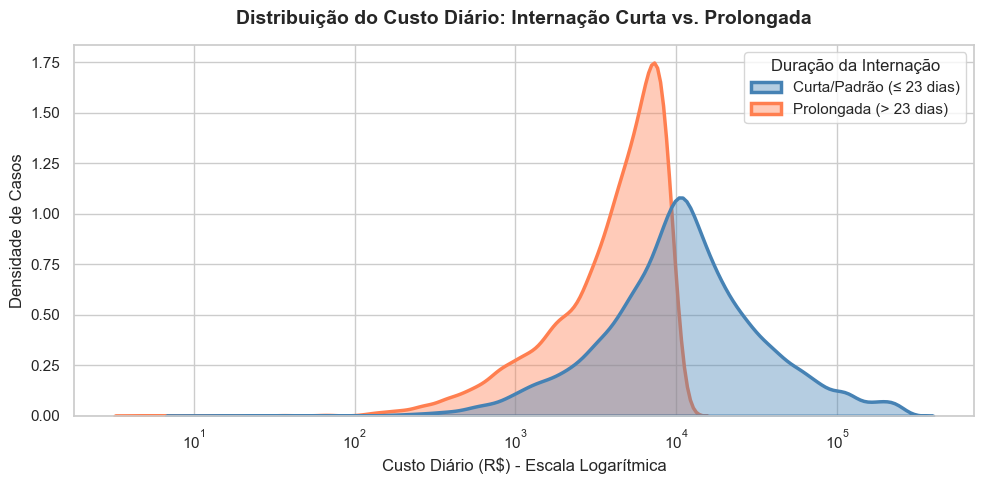

In [206]:
# --- 3. Visualização dos Dados

# Configuração do estilo visual
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))

# Plo das curvas de densidade suavizadas para os dois grupos
sns.kdeplot(
    data=df_clean,
    x='cost_per_day_br',
    hue='is_long_stay',
    fill=True,
    common_norm=False,  # normaliza cada grupo individualmente para equilibrar os tamanhos das áreas
    palette={0: 'steelblue', 1: 'coral'},
    alpha=0.4,
    linewidth=2.5,
    log_scale=True,     # aplica o log no eixo X
    ax=ax
)

# Customização de títulos e rótulos para apresentação
ax.set_title('Distribuição do Custo Diário: Internação Curta vs. Prolongada', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Custo Diário (R$) - Escala Logarítmica', fontsize=12)
ax.set_ylabel('Densidade de Casos', fontsize=12)

# Customização da legenda para termos termos claros de negócio
legend = ax.get_legend()
legend.set_title("Duração da Internação")
for t, label in zip(legend.get_texts(), ["Curta/Padrão (≤ 23 dias)", "Prolongada (> 23 dias)"]):
    t.set_text(label)

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.savefig('analise_tempo_internação.png', dpi=300, bbox_inches='tight')
plt.show()

**=== Interpretação do Gráfico: Distribuição do Custo Diário (Internação curta vs Prolongada) ===**

* A curva das internações prolongadas (laranja) possui uma variância visivelmente menor e um pico (moda) deslocado para a esquerda, enquanto a curva das internações curtas (azul) é muito mais dispersa, estendendo-se até a cauda de altíssimo custo.

* **`Insight de Negócio:`** para a operadora de saúde, as internações curtas (azul) representam risco de volatilidade financeira de curto prazo, pois contêm os picos de custo diário que ultrapassam R$ 100.000. Esse comportamento é típico de eventos agudos de alta complexidade, exigindo auditoria médica rigorosa e negociação prévia de pacotes cirúrgicos com a rede credenciada para mitigar o risco de tabelas abertas (fee-for-service).

* **`Insight de Negócio:`** os custos mais críticos e agressivos (cirurgia, UTI inicial, exames complexos, órteses e próteses) acontecem no início da internação. À medida que o paciente evolui para a estabilização e passa a ocupar apenas o leito para recuperação (hotelaria hospitalar), o custo diário despenca.
* **`Insight de Negócio:`** aparentemente há estratégia de desospitalização. O cenário apresentado valida programas de transição de cuidados, como o Home Care (internação domiciliar). Pacientes que entram na curva laranja (longa permanência) devem ser transferidos para o ambiente domiciliar após o 23º dia se clinicamente estáveis, liberando leitos hospitalares de alto custo operacional e reduzindo ainda mais a sinistralidade da carteira.


In [210]:
# === FEATURE ENGINEERING: CASOS CATASTRÓFICOS ===

# --- 1. Criação da Feature 'is_catastrophic_case'
# Nota Técnica: 'billing_amount_br' mostrou distribuição simétrica,
# 'cost_per_day_br' mostrou distribuições diferentes (cauda longa), sendo o
# escolhido para criar a nova feature
# Nota de Negócio: Feature permite analisar os acionamentos de alto custo

# --- 2. Cálculo do IQR para Custo por Dia
Q1 = df_clean['cost_per_day_br'].quantile(0.25)
Q3 = df_clean['cost_per_day_br'].quantile(0.75)
IQR = Q3 - Q1

# --- 3. O limite superior define onde começam os outliers
limite_superior = Q3 + 1.5 * IQR

# --- 4. Criação da feature binária
df_clean['is_catastrophic_case'] = (df_clean['cost_per_day_br'] > limite_superior).astype(int)

print("✅ Criação da Feature 'is_catastrophic_case' Concluída\n" + '=' * 65)
print(f"* Casos acima de R$ {limite_superior:.2f} foram marcados como catastróficos")
print(f"* Quantidade de Casos Catastróficos: {df_clean['is_catastrophic_case'].sum()} de {len(df_clean)} registros")
print(f"* Representatividade de Casos Catastróficos: {df_clean['is_catastrophic_case'].mean() * 100:.2f}%")

✅ Criação da Feature 'is_catastrophic_case' Concluída
* Casos acima de R$ 33702.51 foram marcados como catastróficos
* Quantidade de Casos Catastróficos: 6127 de 54860 registros
* Representatividade de Casos Catastróficos: 11.17%


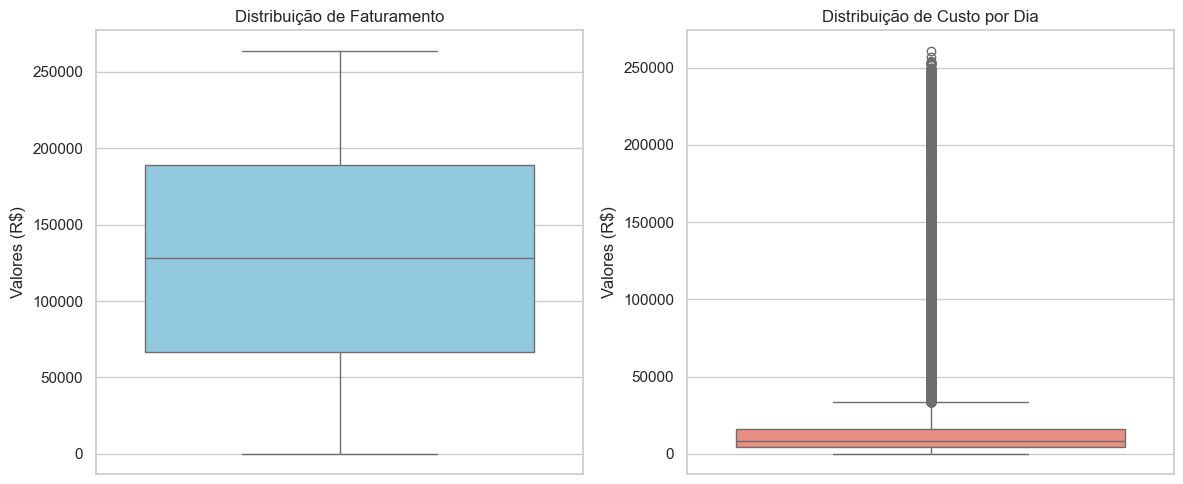

<Figure size 640x480 with 0 Axes>

In [212]:
# --- 5. Visualização dos Dados
# Nota Técnica: boxplot para análise de custos por internação 
# e por dia para análise de outliers

# Criação a área do gráfico para dois subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Boxplot para Faturamento
sns.boxplot(y=df_clean['billing_amount_br'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição de Faturamento')
axes[0].set_ylabel('Valores (R$)')

# --- Boxplot para Custo por Dia
sns.boxplot(y=df_clean['cost_per_day_br'], ax=axes[1], color='salmon')
axes[1].set_title('Distribuição de Custo por Dia')
axes[1].set_ylabel('Valores (R$)')

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.show()
plt.savefig('boxplot_custos.png', dpi=300)

In [ ]:
# === FEATURE ENGINEERING: INTERAÇÃO DIAGNÓTICO E MEDICAÇÃO ===

# --- 7. Criação da Feature 'condition_medication'
# Nota de Negócio: Interação combinada de diagnóstico e medicamentos pode indicar alto custo
# Nota Técnica: Feature de agrupamento para avaliar a interação Diagnóstico x Medicamento X Custo Diário
df_clean.loc[:, 'condition_medication'] = df_clean['medical_condition'] + '_' + df_clean['medication']

print("✅ Criação da Feature 'condition_medication' Concluída")
print('=' * 90)

print("\n📊 Análise de Longa Permanência e Custos por Condição/Medicamento:\n" + '=' * 90)

# Agrupamento usando dicionário para especificar a métrica de cada coluna
df_analise = df_clean.groupby('condition_medication').agg(
    custo_diario_medio=('cost_per_day_br', 'mean'),           # custo diário médio
    total_pacientes=('is_long_stay', 'count'),                # total de pacientes
    casos_long_stay=('is_long_stay', 'sum'),                  # casos de longa permanência (>23 dias)
    taxa_proporcao=('is_long_stay', 'mean')                   # % de internação prolongada no referido grupo
).round(4)

# Formatação visual da taxa em porcentagem
df_analise['taxa_proporcao'] = (df_analise['taxa_proporcao'] * 100).map('{:.2f}%'.format)

# Formatação visual do custo em Real brasileiro (R$)
df_analise['custo_diario_medio'] = df_analise['custo_diario_medio'].map('R$ {:.2f}'.format)

# Ordena pelos grupos que geram mais casos de internação longa
df_analise = df_analise.sort_values(by='custo_diario_medio', ascending=False)

display(df_analise)

✅ Criação da Feature 'condition_medication' Concluída

📊 Análise de Longa Permanência e Custos por Condição/Medicamento:


,custo_diario_medio,total_pacientes,casos_long_stay,taxa_proporcao
condition_medication,,,,
Arthritis_Ibuprofen,R$ 18434.19,1804,414,22.95%
Asthma_Penicillin,R$ 18238.37,1824,440,24.12%
Hypertension_Lipitor,R$ 18100.47,1818,412,22.66%
Obesity_Aspirin,R$ 18008.25,1848,403,21.81%
Hypertension_Ibuprofen,R$ 17960.43,1869,404,21.62%
Obesity_Ibuprofen,R$ 17932.45,1833,418,22.80%
Obesity_Penicillin,R$ 17796.49,1869,410,21.94%
Diabetes_Penicillin,R$ 17657.63,1859,442,23.78%
Diabetes_Paracetamol,R$ 17636.70,1791,426,23.79%


In [ ]:
# === ANÁLISE DE SAZONALIDADE ===

# Análise do período analisado
print("✅ Análise do Período Analisado Concluída:\n" + '=' * 45)
print(f"* Data Mínima: {df_clean['date_of_admission'].min()}.")
print(f"* Data Máxima: {df_clean['date_of_admission'].max()}.")

✅ Análise do Período Analisado Concluída:
* Data Mínima: 2019-05-08 00:00:00.
* Data Máxima: 2024-05-07 00:00:00.


📊 Volume Acumulado de Internações por Mês (Período de 5 anos):
Mês 01 | Total de Admissões: 4646   | Média Anual Estimada: 774
Mês 02 | Total de Admissões: 4199   | Média Anual Estimada: 699
Mês 03 | Total de Admissões: 4610   | Média Anual Estimada: 768
Mês 04 | Total de Admissões: 4466   | Média Anual Estimada: 744
Mês 05 | Total de Admissões: 4547   | Média Anual Estimada: 757
Mês 06 | Total de Admissões: 4640   | Média Anual Estimada: 773
Mês 07 | Total de Admissões: 4762   | Média Anual Estimada: 793
Mês 08 | Total de Admissões: 4777   | Média Anual Estimada: 796
Mês 09 | Total de Admissões: 4503   | Média Anual Estimada: 750
Mês 10 | Total de Admissões: 4605   | Média Anual Estimada: 767
Mês 11 | Total de Admissões: 4501   | Média Anual Estimada: 750
Mês 12 | Total de Admissões: 4604   | Média Anual Estimada: 767


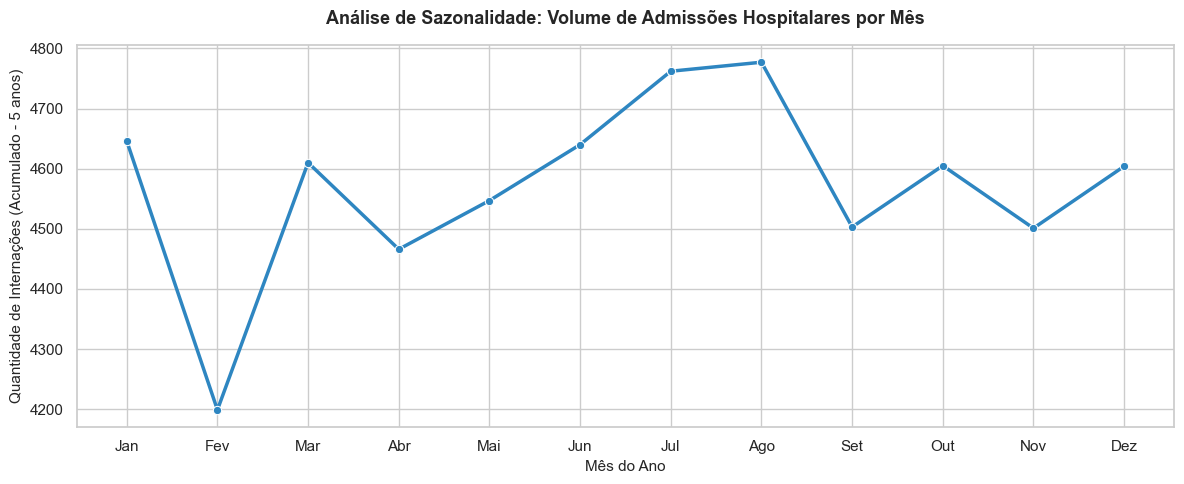

In [146]:
# Extração do Mês e do Ano da data de admissão
df_clean.loc[:, 'admission_month'] = df_clean['date_of_admission'].dt.month
df_clean.loc[:, 'admission_year'] = df_clean['date_of_admission'].dt.year

# Agrupamento para contar o volume de internações por mês (Acumulado dos 5 anos)
sazonalidade = df_clean['admission_month'].value_counts().sort_index()

print("📊 Volume Acumulado de Internações por Mês (Período de 5 anos):")
print('=' * 70)
for mes, qtd in zip(sazonalidade.index, sazonalidade.values):
    print(f"Mês {mes:02d} | Total de Admissões: {qtd:<6} | Média Anual Estimada: {int(qtd/6)}")
print('=' * 70)

# Plotagem do Gráfico de Linha (Análise Temporal)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 5))

# Plotando a linha com marcadores nos pontos
sns.lineplot(x=sazonalidade.index, y=sazonalidade.values, marker='o', color='#2E86C1', linewidth=2.5, ax=ax)

# Customização do gráfico
ax.set_title('Análise de Sazonalidade: Volume de Admissões Hospitalares por Mês', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Mês do Ano', fontsize=11)
ax.set_ylabel('Quantidade de Internações (Acumulado - 5 anos)', fontsize=11)

# Configurando o eixo X para exibir os nomes dos meses
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

# Ajustando o layout e salvando a imagem
plt.tight_layout()
plt.savefig('sazonalidade_internacoes.png', dpi=300)

### Resumo Executivo: Etapa 1 - Análise Exploratória dos Dados

**Limpeza e Tratamento dos Dados**



| Etapa / Iniciativa | Ação Aplicada | Impacto / Justificativa de Negócio | Métrica / Resultado |
| :--- | :--- | :--- | :--- |
| **Padronização de Nomenclatura** | 1. Conversão dos nomes das colunas (*lowercase + separação das palavras por underscore*); <br> 2. Conversão dos registros da coluna `name` para letras minúsculas (*lowercase*). | Elimina duplicidades ocultas geradas por inconsistências de digitação. | **100% das colunas** e nomes padronizados em caixa baixa. |
| **Tipagem de Variáveis** | Conversão de `date_of_admission` e `discharge_date` de tipo texto (*object*) para `datetime64[ns]`. | Permite a execução de cálculos matemáticos e lógicos utilizando eixos temporais. | Tipagem corrigida para **Datetime**. |
| **Ajuste Numérico** | Formatação do faturamento bruto (`billing_amount`) para duas casas decimais (`.2f`). | Alinhamento com o padrão financeiro de análise de custos médicos. | Valores normalizados em escala monetária. |
| **Tratamento de Duplicados** | Identificação e remoção de linhas 100% idênticas no banco de dados. | Eliminação de registros redundantes causados por possíveis falhas de integração ou reenvio de lotes de guias. | **534 linhas duplicadas removidas** (Base reduzida para 54.966 linhas). |
| **Consistência Temporal** | Validação da regra de negócio: Data de Alta $\ge$ Data de Admissão. | Garantia de integridade cronológica dos eventos assistenciais de saúde. | **0 inconsistências** detectadas. |
| **Tratamento de Anomalias (Valores Negativos)** | Exclusão de 106 registros com faturamento menor que zero (`billing_amount < 0`). | Eliminação de ruídos (glosas médicas totais ou erros de sistema) que distorceriam a modelagem de custo bruto do sinistro. | **106 linhas removidas** (0.19% da base). Base final: **54.860 linhas**. |


**Featura Engineering**

| Etapa / Iniciativa | Ação Aplicada | Impacto / Justificativa de Negócio | Métrica / Resultado |
| :--- | :--- | :--- | :--- |
| **Feature Engineering** <br> *`length_of_stay`* | 1. Criação da variável `length_of_stay` através da subtração das datas (Alta - Admissão). | Geração do indicador de **Tempo de Internação**, um dos principais *drivers* de custo e severidade do sinistro na saúde complementar. | Nova feature criada com **média de 15,5 dias** de internação (Mín: 1 / Máx: 30). |
| **Feature Engineering** <br> *`billing_amount_br`* | Criação da variável `billing_amount_br` através da aplicação de taxa de câmbio média estável de mercado *(Fator multiplicador: 5.00)*. | Alinhamento da variável alvo (*target*) com a realidade financeira do mercado de saúde suplementar brasileiro, facilitando a interpretação de custos e tomada de decisão executiva. | Nova escala da **Variável Alvo** estabelecida em moeda nacional, apresentando uma **média de custo de R$ 127.973,17** por internação (Mín: R$ 46,20 / Máx: R$ 263.821,40). |
| **Feature Engineering** <br> *`cost_per_day_br`* | Criação do indicador de custo diário através da divisão do faturamento bruto em Reais (`billing_amount_br`) pelo tempo de permanência hospitalar (`length_of_stay`). | Normaliza a visão de custos da carteira ao neutralizar o efeito do tempo de internação, permitindo que o modelo diferencie procedimentos cirúrgicos rápidos/caros de internações clínicas longas/crônicas. | Nova feature gerada com **custo diário médio de R$ 16.995,66** (Mediana: R$ 8.264,67). Identificada forte assimetria à direita (*cauda longa*) com desvio padrão de R$ 29.007,17 e teto de risco atingindo R$ 261.059,25 por dia. |
| **Feature Engineering** <br> *`age_group`* | Categorização da idade em 10 intervalos regulatórios baseados na Resolução Normativa RN nº 563 da ANS, blindando o teto biológico para um limite seguro de 120 anos. | Permite mapear a distribuição demográfica da carteira e capturar a variação de risco assistencial por ciclo de vida, um dos fatores mais críticos na precificação e predição de sinistros. | Variável gerada evidenciando forte concentração no grupo de **59 anos ou mais (39,56% da carteira)**. Contrariando o padrão biológico esperado, o custo total médio, o tempo de internação e o custo diário mantiveram-se homogêneos em todas as faixas etárias (estáveis em **~15,5 dias**, **~R$ 128.000,00** e **~R$ 17.000,00/dia**). <br><br> **`Insight de Negócio (Mutualismo):`** A distribuição indica uma carteira de altíssimo risco demográfico e baixa renovação (falta de beneficiários jovens para subsidiar o custo dos mais idosos). <br><br> **`Impacto para a Modelagem:`** Como a idade não gera quebras expressivas de variação de custo ou permanência, o algoritmo de Machine Learning provavelmente atribuirá baixa importância preditiva (*feature importance*) para a idade. |
| **Feature Engineering** <br> *`is_weekend_admission`* | Identificação de internações ocorridas aos finais de semana (sábados e domingos) mapeadas a partir da data de admissão. | Avaliar se a sazonalidade semanal impacta o custo assistencial, uma vez que na vida real a ausência de leitos eletivos e o regime de plantão hospitalar costumam inflacionar guias de urgência. | Variável gerada evidenciando **39.212 casos em dias úteis** e **15.648 em finais de semana**. Utilizando o custo diário (`cost_per_day_br`) como parâmetro de validação, comprovou-se que não há variação estatística de custo (estável em **~R$ 16.900,00/dia** independente do dia da admissão). <br><br> **`Impacto para a Modelagem:`** Dado o comportamento homogêneo e a ausência de ganho de informação (*Information Gain*), a feature foi descontinuada do pipeline final para garantir a **parcimônia do modelo**, reduzindo ruídos e a complexidade do treinamento. |
| **Feature Engineering** <br> *`is_long_stay`* | Criação de uma flag binária indicando internações de longa permanência (casos que ultrapassaram o terceiro quartil da base, equivalente a $> 23$ dias). | Permite segmentar a carteira entre casos agudos (alto custo concentrado em poucos dias) e casos crônicos de longa permanência hospitalar, auxiliando o modelo a entender o efeito de diluição do custo diário. | Variável gerada com **42.104 casos de curta permanência** e **12.756 de longa permanência**. <br><br> **`Insight de Negócio:`** Identifica sinistros agudos de alto custo das internações clínicas crônicas de longa permanência. <br><br> **`Impacto para a Modelagem:`** Feature demonstrou forte poder de separação: o grupo de curta duração retém a maior severidade diária (**Média de R$ 20.706,34/dia**), enquanto o grupo de longa internação estabiliza em **R$ 4.747,77/dia**. |
| **Feature Engineering** <br> *`condition_medication`* | Criação de uma variável de interação categórica combinando o diagnóstico clínico (`medical_condition`) com o protocolo farmacológico prescrito (`medication`). | Mapear a severidade e a complexidade do sinistro com base no cruzamento entre a patologia do paciente e o medicamento utilizado no tratamento hospitalar. | Variável gerada consolidando 30 combinações únicas. Os indicadores financeiros mantiveram-se homogêneos entre todos os cruzamentos (médias estáveis em **~R$ 128.000,00** de custo total). <br><br> **`Insight de Negócio:`** Evidencia a necessidade de auditoria médica concorrente, uma vez que o custo do sinistro se mostra plano e indiferente à complexidade do tratamento aplicado, sugerindo que o hospital cobra o mesmo valor fixo 'de pacote' independente do que faz com o paciente. |
| **Feature Engineering** <br> *`is_catastrophic_case`* | Criação de uma flag binária para mapear casos de altíssimo impacto financeiro. Baseando-se no comportamento assimétrico de cauda longa do custo diário (`cost_per_day_br`), o limiar de corte foi estabelecido para diárias superiores a **R$ 33.702,51** *(limite estatístico de outliers superiores)*. | Permite à operadora monitorar e prever sinistros catastróficos de forma isolada, viabilizando estratégias de gerenciamento de pacientes de alto custo, auditoria médica focada e mitigação de risco de cauda (*tail risk*). | Feature gerada identificando **6.127 acionamentos catastróficos**, representando **11,17% da carteira**. O boxplot validou a eficiência do corte, segregando a cauda de volatilidade que atinge o pico de R$ 261.059,25 por dia. <br><br> **`Insight de Negócio:`** Revela que a severidade financeira da carteira está concentrada em uma fatia estreita de utilização. <br><br> **`Impacto para a Modelagem:`** Entrega ao algoritmo um sinal booleano limpo e de alta relevância. |
| **Feature Engineering** <br> *`admission_month`* | Extração do mês de admissão hospitalar a partir da variável contínua `date_of_admission` para avaliar ciclos sazonais acumulados no período de 5 anos. | Identificar picos sazonais de internação (como surtos de doenças respiratórias no inverno) que pudessem atuar como preditores de frequência e severidade de sinistro. | Identificou-se uma distribuição volumétrica uniforme, variando estritamente entre **4.199** (Fev) e **4.777** (Ago) internações acumuladas. <br><br> **`Insight de Negócio:`** A sutil variação (~12%) deve-se ao número de dias calendário (como o vale natural de Fevereiro) e não a padrões sazonais de saúde, reforçando a independência estatística do tempo neste ecossistema. <br><br> **`Impacto para a Modelagem:`** A feature foi **descontinuada** do pipeline preditivo devido à ausência de variância relevante e ganho de informação. |

## Etapa 2: Análise das Features para Modelagem